# Notebook to Compile Dataset for ML Training & Evaluation
<img src="../data/img/data_aggregation.jpg" width="300" height="150">

## Import modules

In [1]:
import os
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
repo_root = next((p for p in [cwd, *cwd.parents] if p.name == 'pips-design-toolkit'), None)
if repo_root is None:
    raise RuntimeError('Run this notebook from within the pips-design-toolkit repository.')
tools_dir = repo_root / "tools"
os.chdir(tools_dir)
if str(tools_dir) not in sys.path:
    sys.path.insert(0, str(tools_dir))
from utils.variables import data_folder, subfolders
from compile_analyse_dataset import aggregate_features

## Specify input parameters
* *Data subfolder name* (`data_subfolder`): Subfolder name for saving data to. Can be an empty string.
* *Dict of feature types to include in dataset (follow format in example)* (`feature_types_to_include`): e.g. {'ylabel': ('GOh1052_mutagenesis.csv',['CategoryV3', 'Fold (Max Abs)'], ['mutations','fold_random_5']), 'sequences': 'GOh1052.fasta', 'binding_yasara': 'DDGbind_GOh1052.csv'}
* *Output CSV filename* (`output_csv_fname`): CSV filepath in data folder for saving compiled dataset to
* *Output CSV directory* (`output_csv_dir`): Subfolder containing compiled dataset
* *Separator string for joining mutations in combinatorial mutant* (`sep`): Default='+', e.g. 'A21V+E50K'
* *Bool indicating whether to deduplicate entries in dataset* (`deduplicate_entries`): True or False

In [2]:
data_subfolder =  '' 
fname_prefix = 'GOh1052_'
feature_types_to_include = {
    'ylabel': ('GOh1052_mutagenesis.csv',
               ['CategoryV3', 'Fold (Max Abs)'], ['mutations','fold_random_5']),
    # 'sequences': 'GOh1052.fasta',
    'binding_yasara': 'DDGbind_GOh1052.csv',
    'stability_foldx': 'DDGstability_GOh1052.csv',
    'tango': 'AggregationScore_GOh1052_tango.csv',
    'waltz': 'AggregationScore_GOh1052_waltz.csv',
    'esm2_llr_entropy': 'GOh1052_esm2-33_LLRsum_entropy.csv'
}
output_csv_fname = 'GOh1052_AggStabBind-mut.csv'
output_csv_dir = data_folder + subfolders['ml_prediction'] + 'Input/' + data_subfolder + '/'
sep = '+'
deduplicate_entries = False

## Compile dataset
Compile dataset comprising various scores & features specified.

Resulting CSV dataset is saved at: <`output_csv_dir`>/<`output_csv_fname`>

In [3]:
data_all, features_all = aggregate_features(feature_types_to_include, data_folder, data_subfolder, output_csv_fname, output_csv_dir, deduplicate_entries=deduplicate_entries, WT_or_MT='MT', sep=sep, fname_prefix=fname_prefix)

expdata: (6686, 5)
binding_yasara: (6686, 22)
Processed "binding_yasara" features >> (6686, 27)
stability_foldx: (6686, 31)
Processed "stability_foldx" features >> (6686, 57)
tango: (12636, 9)
Processed "tango" features >> (12636, 65)
diff mut (ylabel <> tango): 5950
waltz: (12636, 3)
Processed "waltz" features >> (12636, 67)
diff mut (ylabel <> waltz): 5950
Processed pLM LLR and entropy features >> (12636, 73)
final data (non-null): (6686, 73)
Saved aggregated data to: ../data/ml_prediction/Input//GOh1052_AggStabBind-mut.csv /Users/charmainechia/Documents/projects/pips-design-toolkit/data/ml_prediction/Input/GOh1052_AggStabBind-mut.csv


Spearman R: 0.647; Pearson R 0.638


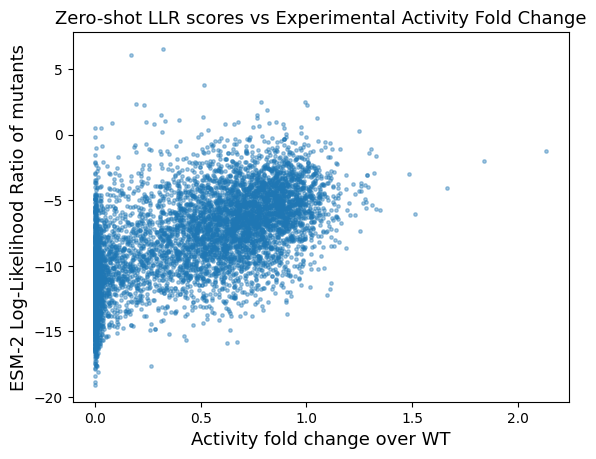

Spearman R: 0.969; Pearson R 0.955


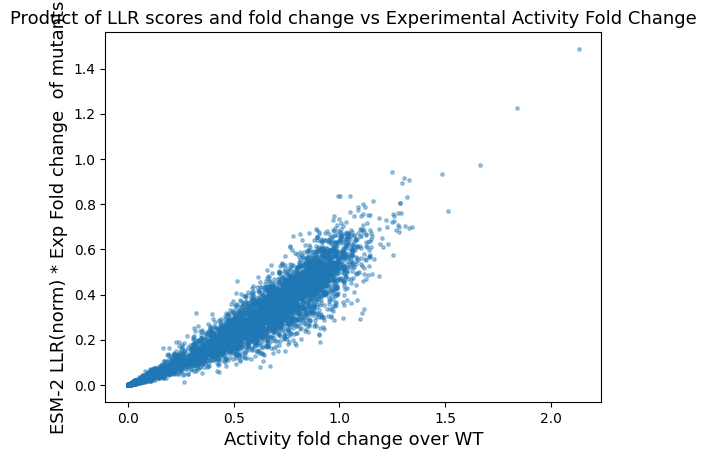

In [6]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr
data_all_filt = data_all.copy() # data_all[data_all['Fold (Max Abs)']<1.5]
x = data_all_filt['Fold (Max Abs)'].to_numpy()
y1 = data_all_filt['LLR'].to_numpy()
y2 = data_all_filt['LLR_norm'].to_numpy() * x
corr_s = round(spearmanr(x,y1)[0],3)
corr_p = round(pearsonr(x,y1)[0],3)
print(f'Spearman R: {corr_s}; Pearson R {corr_p}')
plt.scatter(x, y1, s=6, alpha=0.4)
plt.xlabel('Activity fold change over WT', fontsize=13)
plt.ylabel('ESM-2 Log-Likelihood Ratio of mutants', fontsize=13)
plt.title('Zero-shot LLR scores vs Experimental Activity Fold Change', fontsize=13)
plt.show()

corr_s = round(spearmanr(x,y2)[0],3)
corr_p = round(pearsonr(x,y2)[0],3)
print(f'Spearman R: {corr_s}; Pearson R {corr_p}')
plt.scatter(x, y2, s=6, alpha=0.4)
plt.xlabel('Activity fold change over WT', fontsize=13)
plt.ylabel('ESM-2 LLR(norm) * Exp Fold change  of mutants', fontsize=13)
plt.title('Product of LLR scores and fold change vs Experimental Activity Fold Change', fontsize=13)
plt.show()

In [26]:
muts = data_all.mutations.tolist()
pos = list(set([int(mut[1:-1]) for mut in muts]))
pos.sort()
print(len(pos))

352
